# Latent Time Series
Some text here.

In [24]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

In [25]:
# data wrangling
import numpy as np
import pandas as pd

def prepare_ordered_monthly_data(df, month_col="mmYYYY", rating_col="stars"):
    """
    Prepare monthly ordered-rating data for a latent monthly-state model.

    Expected input:
      - month_col: strings like '02-2026'
      - rating_col: ordered ratings, assumed here to be 1..5

    This helper:
      - parses month strings
      - creates a complete monthly sequence including empty months
      - recodes ratings from 1..5 to 0..4
      - forces integer arrays to int64 for PyMC/PyTensor stability

    Returns a dict with:
      - df_reviews
      - month_df
      - ratings
      - month_idx_for_review
      - month_labels
      - n_months
      - n_cats
    """

    out = df.copy()

    # Parse month strings and coerce to month-start timestamps
    out[month_col] = pd.to_datetime(out[month_col], format="%m-%Y")
    out[month_col] = out[month_col].dt.to_period("M").dt.to_timestamp()

    # Ratings: assume raw values are 1..5, convert to 0..4
    out[rating_col] = out[rating_col].astype(np.int64)
    out[rating_col] = out[rating_col] - 1

    # Optional sanity check
    unique_ratings = np.sort(out[rating_col].unique())
    if not np.array_equal(unique_ratings, np.arange(unique_ratings.min(), unique_ratings.max() + 1)):
        raise ValueError(
            f"Ratings must be consecutive after recoding. Got: {unique_ratings}"
        )

    # Build full monthly span, including months with no reviews
    min_month = out[month_col].min()
    max_month = out[month_col].max()
    all_months = pd.date_range(min_month, max_month, freq="MS")

    month_df = pd.DataFrame({"month": all_months})
    month_df["month_idx"] = np.arange(len(month_df), dtype=np.int64)
    month_df["month_label"] = month_df["month"].dt.strftime("%m-%Y")

    # Review-level data joined to month index
    df_reviews = out.rename(columns={month_col: "month", rating_col: "rating"}).copy()
    df_reviews = df_reviews.merge(month_df, on="month", how="left")
    df_reviews = df_reviews.sort_values(["month", "rating"]).reset_index(drop=True)

    ratings = df_reviews["rating"].to_numpy(dtype=np.int64)
    month_idx_for_review = df_reviews["month_idx"].to_numpy(dtype=np.int64)

    n_cats = int(ratings.max()) + 1
    n_months = len(month_df)

    return {
        "df_reviews": df_reviews,
        "month_df": month_df,
        "ratings": ratings,
        "month_idx_for_review": month_idx_for_review,
        "month_labels": month_df["month_label"].tolist(),
        "n_months": n_months,
        "n_cats": n_cats,
    }

In [26]:
# Build the model
# Montly ordered probit for observation model
# Assumed random walk for latent trait

def build_monthly_ordered_probit_model(
    data_dict,
    init_mu=0.0,
    init_sigma=1.0, # how much intial variance
    drift_sigma=0.15, # how much drift per-month
):
    """
    Ordered probit with latent monthly state theta_month.

    theta evolves as a Gaussian random walk with small step size.
    """
    ratings = data_dict["ratings"]
    month_idx_for_review = data_dict["month_idx_for_review"]
    n_months = data_dict["n_months"]
    n_cats = data_dict["n_cats"]

    with pm.Model() as model:
        # Latent month states
        theta_month = pm.GaussianRandomWalk( # syntactic sugar
            "theta_month",
            sigma=drift_sigma,
            shape=n_months,
            init_dist=pm.Normal.dist(mu=init_mu, sigma=init_sigma),
        )

        # Ordered cutpoints for K categories => K-1 cutpoints
        cutpoints = pm.Normal(
            "cutpoints",
            mu=np.linspace(-2, 2, n_cats - 1),
            sigma=1.5,
            transform=pm.distributions.transforms.ordered,
            shape=n_cats - 1,
        )

        # Each review gets the latent state of its month
        eta = theta_month[month_idx_for_review]

        # Ordered probit likelihood, LOTS of syntactic sugar here...
        # Might redo this more manually for instructive purposes
        y = pm.OrderedProbit(
            "y",
            eta=eta,
            cutpoints=cutpoints,
            observed=ratings,
        )

    return model

In [27]:
# load data from /data
import pandas as pd

df = pd.read_csv("../data/review_timeseries.csv")

# glance at it...
df.head()


,mmYY,stars
0,12-2025,5
1,02-2026,5
2,02-2026,4
3,02-2026,3
4,02-2026,5


In [44]:
# Fitting the model...

data_dict = prepare_ordered_monthly_data(df, month_col="mmYY", rating_col="stars")
model = build_monthly_ordered_probit_model(data_dict, init_mu=0.0, init_sigma=1.0, drift_sigma=0.15)

with model:
    trace = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.9,
        random_seed=99,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [theta_month, cutpoints]


/usr/local/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 50 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [45]:
# Plottin helper
def plot_theta_month(trace, data_dict, prob=0.90):
    theta = trace.posterior["theta_month"].values
    theta = theta.reshape(-1, theta.shape[-1])

    mean_theta = theta.mean(axis=0)
    lower = np.quantile(theta, (1 - prob) / 2, axis=0)
    upper = np.quantile(theta, 1 - (1 - prob) / 2, axis=0)

    labels = data_dict["month_labels"]
    x = np.arange(len(labels))

    # Identify January ticks (prevent over-plotting)
    jan_idx = [i for i, m in enumerate(labels) if m.startswith("01-")]

    plt.figure(figsize=(10, 5))
    plt.plot(x, mean_theta, label="Posterior mean theta")
    plt.fill_between(x, lower, upper, alpha=0.3, label=f"{int(prob*100)}% credible interval")

    plt.xticks(jan_idx, [labels[i] for i in jan_idx], rotation=45, ha="right")

    plt.xlabel("Month")
    plt.ylabel("Latent monthly theta")
    plt.title("Latent monthly state over time")
    plt.legend()
    plt.tight_layout()
    plt.show()

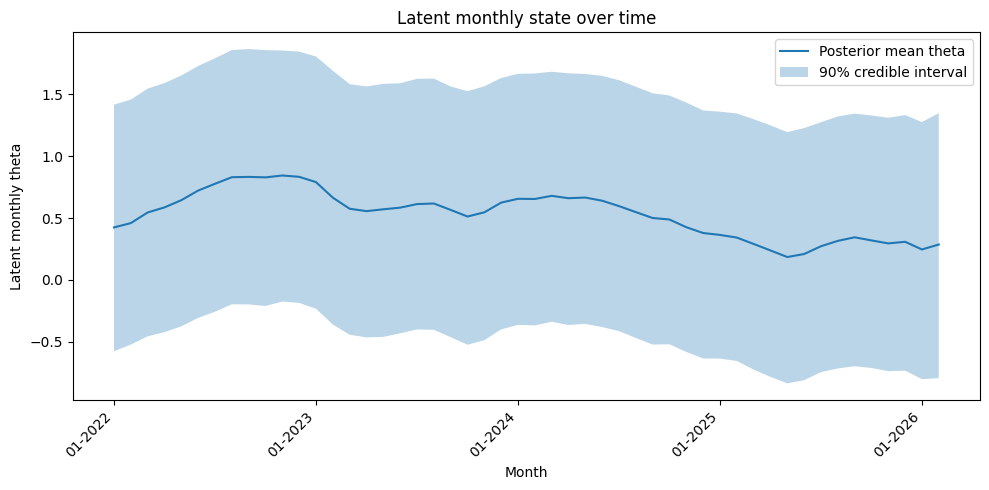

In [46]:
# plot
plot_theta_month(trace, data_dict, prob=0.90)